In [1]:
import numpy as np 
import pandas as pd
df = pd.read_csv('data_science_job.csv')

In [2]:
import matplotlib.pyplot as plt

In [4]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [5]:
cols = [var for var in df.columns if df[var].isnull().mean() <0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [7]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
3384,0.896,Full time course,High School,2.0,54.0
3148,0.910,no_enrollment,Primary School,3.0,48.0
1263,0.527,Full time course,High School,4.0,56.0
13732,0.926,no_enrollment,Masters,20.0,134.0
3054,0.624,no_enrollment,Masters,6.0,92.0


In [8]:
new_df = df[cols].dropna()
new_df.shape , df.shape

((17182, 5), (19158, 13))

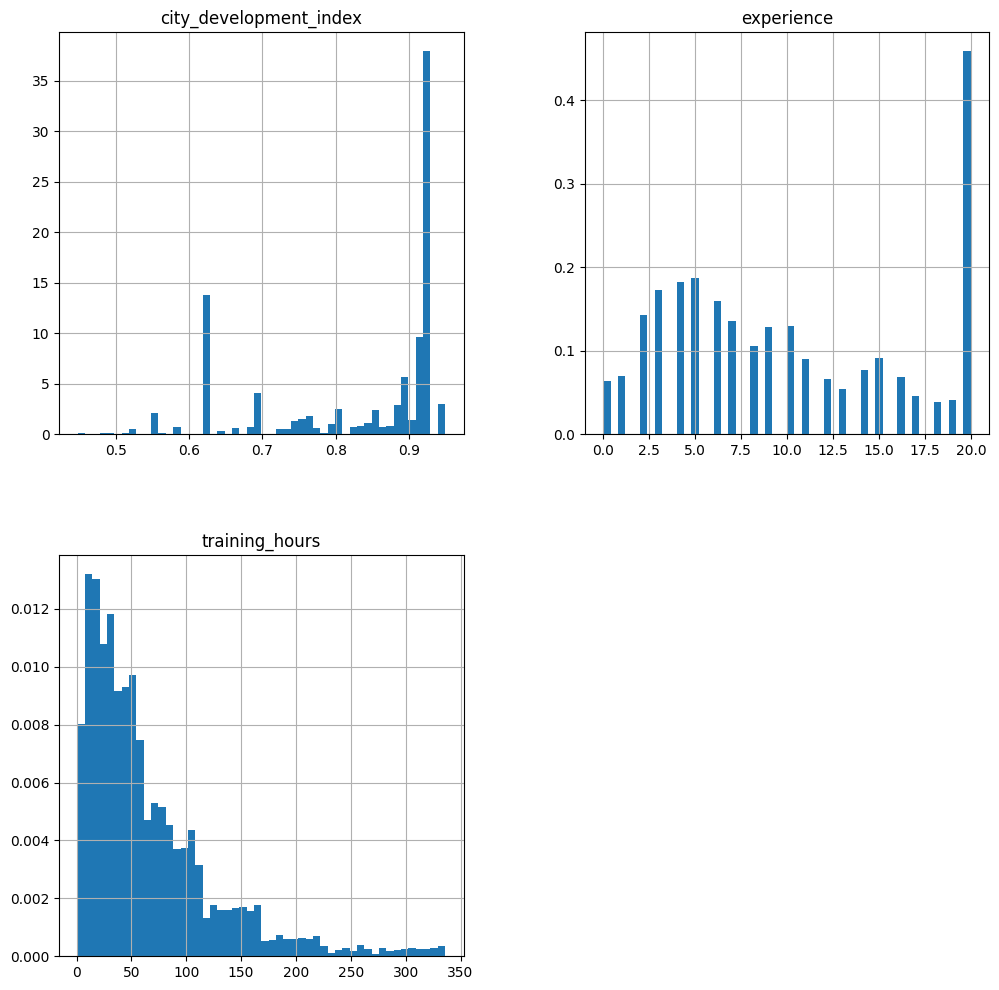

In [9]:
new_df.hist(bins=50 , density = True , figsize=(12,12))
plt.show()

In [11]:
temp = pd.concat([
    # percentage of obeservations per category , orignal data
    df['enrolled_university'].value_counts()/len(df),
    # percentage of obeservations per category , cca data
    df['enrolled_university'].value_counts()/len(new_df)
], 
axis=1)

temp.columns = ['orignal data' , 'cca data']
temp

,orignal data,cca data
enrolled_university,,
no_enrollment,0.721213,0.804156
Full time course,0.196106,0.218659
Part time course,0.062533,0.069724


In [12]:
temp1 = pd.concat([
    df['education_level'].value_counts()/len(df),
    df['education_level'].value_counts()/len(new_df)
],
axis=1)
temp1.columns = ['orignal' , 'cca']
temp1

,orignal,cca
education_level,,
Graduate,0.605387,0.675009
Masters,0.227633,0.253812
High School,0.105282,0.117390
Phd,0.021610,0.024095
Primary School,0.016077,0.017926
